In [2]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import os
from pathlib import Path


In [3]:
TICKERS = ['SPY', "TLT", "GLD", "^VIX"]

In [4]:
data = yf.download(
    TICKERS,
    start="2005-01-01",
    auto_adjust=True,
    progress=False
)

In [5]:
close_prices = data['Close']

In [6]:
close_prices.rename(columns={'^VIX':'VIX'}, inplace=True)

In [7]:
close_prices.head()

Ticker,GLD,SPY,TLT,VIX
Date,,,,
2005-01-03,43.020000,81.383751,44.222534,14.08
2005-01-04,42.740002,80.389236,43.759079,13.98
2005-01-05,42.669998,79.834503,43.993301,14.09
2005-01-06,42.150002,80.240433,44.023212,13.58
2005-01-07,41.840000,80.125412,44.122879,13.49


In [8]:
close_prices.isna().sum()

Ticker
GLD    1
SPY    1
TLT    1
VIX    0
dtype: int64

In [9]:
close_prices.ffill(inplace=True)

Ticker,GLD,SPY,TLT,VIX
Date,,,,
2005-01-03,43.020000,81.383751,44.222534,14.080000
2005-01-04,42.740002,80.389236,43.759079,13.980000
2005-01-05,42.669998,79.834503,43.993301,14.090000
2005-01-06,42.150002,80.240433,44.023212,13.580000
2005-01-07,41.840000,80.125412,44.122879,13.490000
...,...,...,...,...
2026-06-01,411.260010,758.539978,85.470001,16.049999
2026-06-02,411.950012,759.570007,85.650002,15.770000
2026-06-03,407.869995,754.239990,85.309998,16.059999


In [10]:
close_prices.isna().sum()

Ticker
GLD    0
SPY    0
TLT    0
VIX    0
dtype: int64

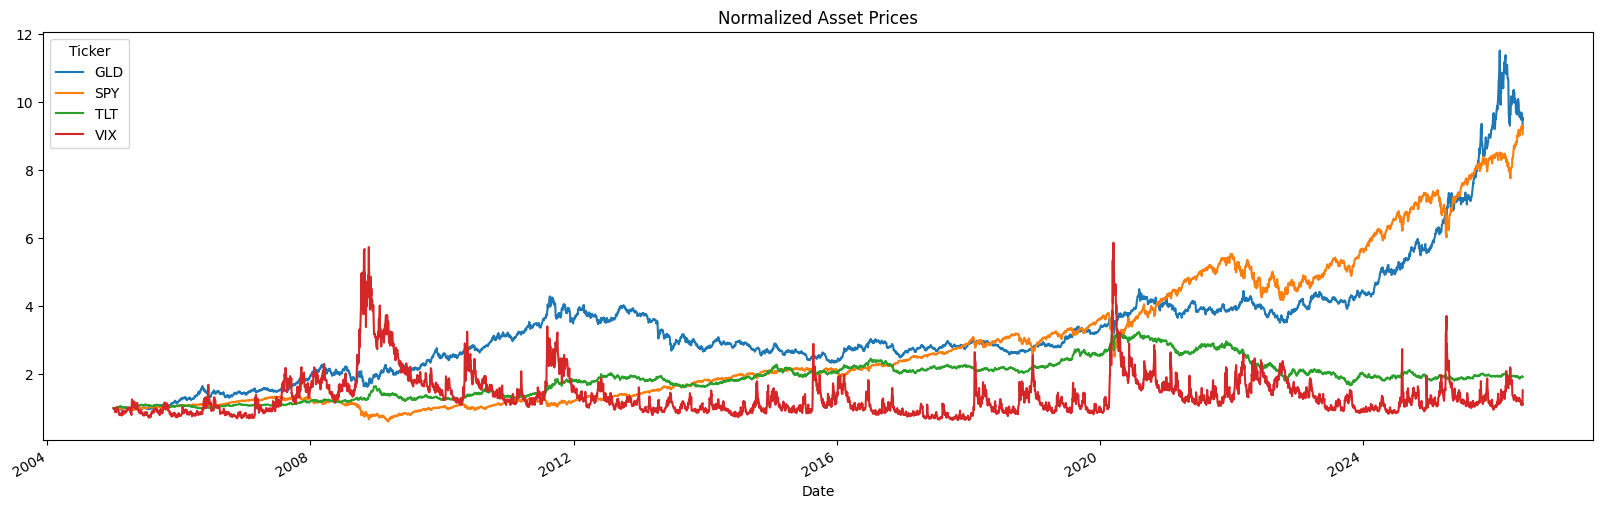

In [11]:
import matplotlib.pyplot as plt

(close_prices / close_prices.iloc[0]).plot(
    figsize=(20,6)
)

plt.title("Normalized Asset Prices")
plt.show()

In [12]:
RAW_PATH = os.path.join("data", 'raw')
file_path = os.path.join(RAW_PATH, "market_prices.csv")
os.makedirs(RAW_PATH, exist_ok=True)
close_prices.to_csv(file_path)